**Name:** Arun Bhaskar Gadde

**Course:** 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-B01) - Second Bi-term

**Assignment:** Project Deliverable 2: Regression Modeling and Performance Evaluation


## 1. Regression Target Selection

The Telco Customer Churn dataset's natural label, `Churn`, is categorical (Yes/No) and is
reserved for the classification deliverable. For this regression deliverable, **`MonthlyCharges`**
is used as the continuous target variable.

**Why `MonthlyCharges`:** a customer's monthly bill is driven by *what they subscribe to* —
phone service, internet type, and add-on services like online security or streaming — plus
contract terms. That makes it a genuine regression problem where feature engineering on the
service-subscription columns should meaningfully improve predictive power, rather than a
trivial one.

**Why not `TotalCharges`:** Deliverable 1's EDA found `TotalCharges` is very strongly
correlated with `tenure` and `MonthlyCharges` (since `TotalCharges` ≈ `tenure` ×
`MonthlyCharges`, accumulated over billing cycles). Modeling `TotalCharges` from those same
variables would be near-deterministic and wouldn't showcase meaningful modeling or feature
engineering, so `tenure` is kept as a predictor of `MonthlyCharges`, but `TotalCharges` is
excluded entirely from the feature set to avoid this collinearity trap.


## 2. Load the Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
np.random.seed(42)

# Load the cleaned dataset produced in Deliverable 1
df = pd.read_csv("data/Telco-Customer-Churn-Cleaned.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Confirm there is no missing data carried over from Deliverable 1's cleaning
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTotal missing values:", df.isnull().sum().sum())


Missing values per column:
Series([], dtype: int64)

Total missing values: 0


## 3. Feature Engineering

Several of the raw columns need to be transformed before they're useful to a regression
model, and a few new features are engineered from the raw service-subscription columns to
better capture customer behavior:

1. **Binary recoding:** columns like `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`,
   and `PaperlessBilling` are Yes/No text — recoded to 0/1.
2. **Collapsing the "No internet/phone service" category:** columns such as `OnlineSecurity`
   or `MultipleLines` use three levels (`Yes` / `No` / `No internet service`), where the third
   level is really just a special case of "No" driven by another column (`InternetService` or
   `PhoneService`). These are collapsed to simple binary flags so the model doesn't treat them
   as three unrelated categories.
3. **Engineered feature — `num_addon_services`:** a count (0-6) of how many optional add-on
   services (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV,
   StreamingMovies) each customer subscribes to. This condenses six sparse binary columns into
   one meaningful "service breadth" signal.
2. **Engineered feature — `contract_length_months`:** `Contract` (Month-to-month/One year/Two
   year) is naturally ordinal, so it is mapped to its numeric length in months (1, 12, 24)
   rather than one-hot encoded, preserving the ordering for the linear models.
5. **One-hot encoding:** the remaining nominal categorical columns (`InternetService`,
   `PaymentMethod`, `gender`) are one-hot encoded since they have no natural order.
6. **Dropped columns:** `customerID` (identifier, no predictive value), `TotalCharges` and
   `Churn` (excluded per the rationale in Section 1), and the six raw add-on columns and
   `Contract` (replaced by their engineered versions above).


In [3]:
df_fe = df.copy()

# 1. Simple binary recoding (Yes/No -> 1/0)
binary_cols = ["SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df_fe[col] = df_fe[col].map({"Yes": 1, "No": 0})

# gender -> binary is_male flag
df_fe["is_male"] = (df_fe["gender"] == "Male").astype(int)

# 2. Collapse "No internet/phone service" into "No" for the add-on service columns
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
for col in addon_cols:
    df_fe[col] = df_fe[col].replace("No internet service", "No").map({"Yes": 1, "No": 0})

df_fe["MultipleLines"] = df_fe["MultipleLines"].replace("No phone service", "No").map({"Yes": 1, "No": 0})

# 3. Engineered feature: number of add-on services subscribed (0-6)
df_fe["num_addon_services"] = df_fe[addon_cols].sum(axis=1)

# 4. Engineered feature: contract length in months (ordinal -> numeric)
contract_map = {"Month-to-month": 1, "One year": 12, "Two year": 24}
df_fe["contract_length_months"] = df_fe["Contract"].map(contract_map)

# 5. One-hot encode remaining nominal categorical columns
df_fe = pd.get_dummies(df_fe, columns=["InternetService", "PaymentMethod"], drop_first=True)

# 6. Drop columns no longer needed: identifiers, target leakage risks, and now-redundant raw columns
drop_cols = ["customerID", "TotalCharges", "Churn", "Contract", "gender"] + addon_cols
df_fe = df_fe.drop(columns=drop_cols)

# Ensure one-hot columns are integer, not boolean, for downstream compatibility
onehot_cols = [c for c in df_fe.columns if c.startswith("InternetService_") or c.startswith("PaymentMethod_")]
df_fe[onehot_cols] = df_fe[onehot_cols].astype(int)

print(f"Engineered feature set shape: {df_fe.shape}")
df_fe.head()


Engineered feature set shape: (7043, 16)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,MonthlyCharges,is_male,num_addon_services,contract_length_months,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,1,29.85,0,1,1,0,0,0,1,0
1,0,0,0,34,1,0,0,56.95,1,2,12,0,0,0,0,1
2,0,0,0,2,1,0,1,53.85,1,2,1,0,0,0,0,1
3,0,0,0,45,0,0,0,42.30,1,3,12,0,0,0,0,0
4,0,0,0,2,1,0,1,70.70,0,0,1,1,0,0,1,0


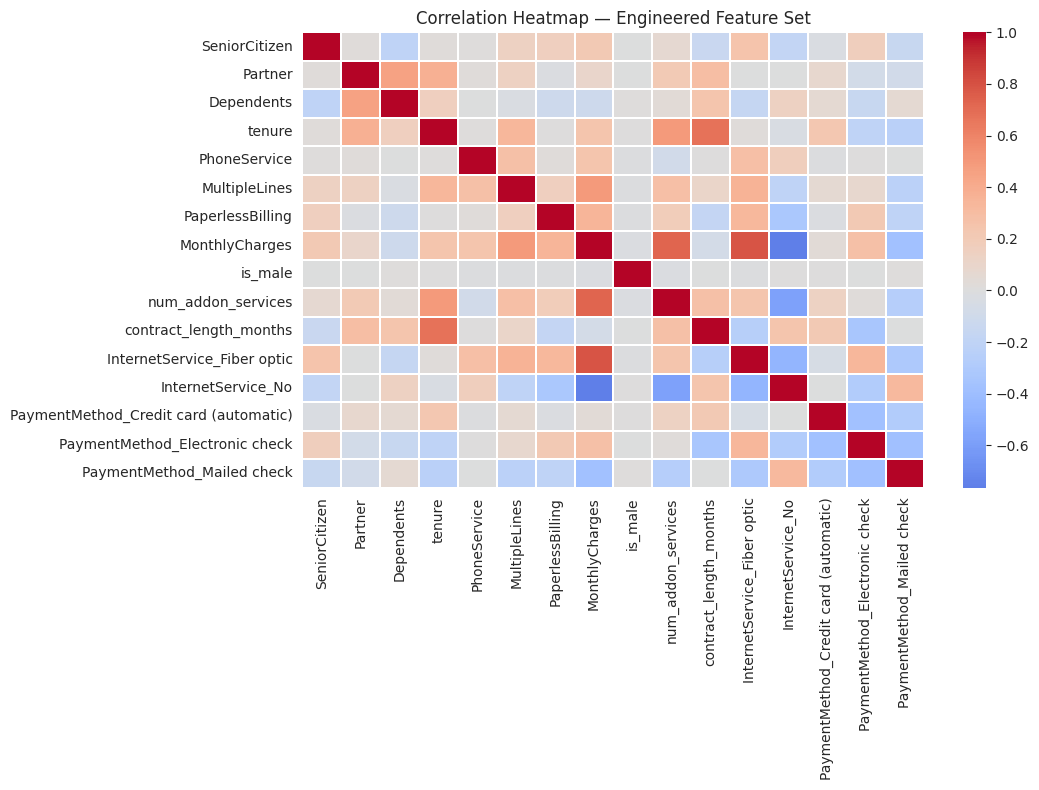

In [4]:
plt.figure(figsize=(11, 8))
corr = df_fe.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation Heatmap — Engineered Feature Set")
plt.tight_layout()
plt.show()


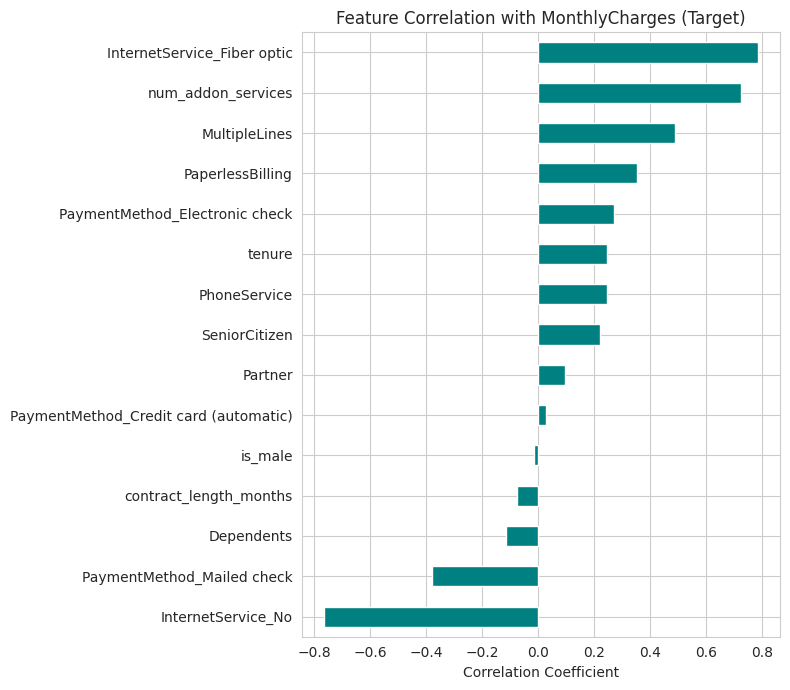

In [5]:
corr["MonthlyCharges"].drop("MonthlyCharges").sort_values().plot(
    kind="barh", figsize=(8, 7), color="teal"
)
plt.title("Feature Correlation with MonthlyCharges (Target)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()


**Observation:** `InternetService_Fiber optic` and `num_addon_services` show the strongest
positive correlation with `MonthlyCharges`, which makes intuitive sense — fiber is the
premium internet tier, and each additional add-on service adds to the bill. `tenure` and
`contract_length_months` show weak correlation with the target, confirming that *what a
customer subscribes to* drives their bill far more than *how long they've been a customer*
— exactly the behavior that motivated using `MonthlyCharges` instead of `TotalCharges`.

## 4. Train/Test Split

In [6]:
target = "MonthlyCharges"
X = df_fe.drop(columns=[target])
y = df_fe[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} rows, {X_test.shape[1]} features")


Training set: 5634 rows, 15 features
Testing set:  1409 rows, 15 features


In [7]:
# Standardize numeric features for the regularized models (Ridge/Lasso are scale-sensitive).
# Linear Regression's coefficients/predictions are unaffected by scaling, so the same
# scaled inputs are used for all models to keep comparisons apples-to-apples.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE:  {mae:.3f}")
    print(f"MSE:  {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2:   {r2:.3f}\n")
    return {"Model": label, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

results = []


## 5. Model 1 — Baseline Linear Regression (Before Feature Engineering)

To demonstrate the value of the feature engineering above, a baseline model is fit first
using only the *raw*, minimally-processed columns available before engineering:
`tenure`, `SeniorCitizen`, `Partner`, `Dependents`, and `PhoneService`. This excludes the
engineered `num_addon_services` and `contract_length_months` features, and excludes the
one-hot encoded service/payment columns entirely — approximating what a first-pass model
would look like without the feature engineering step.

In [8]:
baseline_features = ["tenure", "SeniorCitizen", "Partner", "Dependents", "PhoneService"]

X_train_base = X_train_scaled[baseline_features]
X_test_base = X_test_scaled[baseline_features]

baseline_model = LinearRegression()
baseline_model.fit(X_train_base, y_train)
y_pred_base = baseline_model.predict(X_test_base)

results.append(evaluate(y_test, y_pred_base, "Baseline Linear Regression (raw features only)"))


--- Baseline Linear Regression (raw features only) ---
MAE:  22.630
MSE:  760.650
RMSE: 27.580
R2:   0.160



## 6. Model 2 — Multiple Regression (Full Engineered Feature Set)

Now the same Linear Regression algorithm is trained on the **full engineered feature set**
— including `num_addon_services`, `contract_length_months`, and the one-hot encoded
service/payment columns — to isolate how much the feature engineering itself improves
performance, independent of any regularization.

In [9]:
multiple_model = LinearRegression()
multiple_model.fit(X_train_scaled, y_train)
y_pred_multi = multiple_model.predict(X_test_scaled)

results.append(evaluate(y_test, y_pred_multi, "Multiple Regression (engineered features)"))


--- Multiple Regression (engineered features) ---
MAE:  1.973
MSE:  7.102
RMSE: 2.665
R2:   0.992



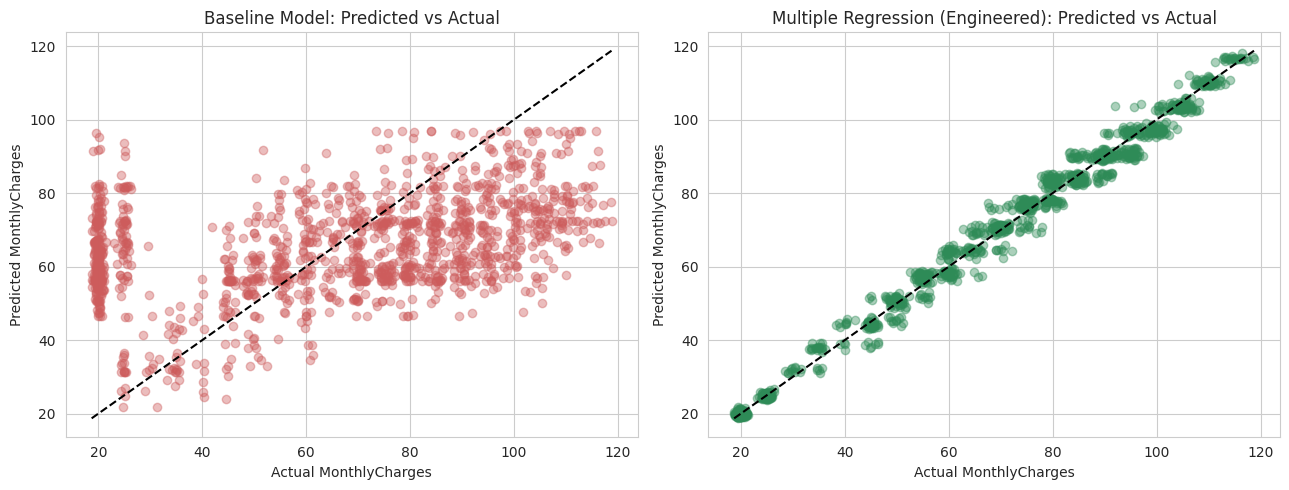

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_base, alpha=0.4, color="indianred")
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "k--")
axes[0].set_xlabel("Actual MonthlyCharges")
axes[0].set_ylabel("Predicted MonthlyCharges")
axes[0].set_title("Baseline Model: Predicted vs Actual")

axes[1].scatter(y_test, y_pred_multi, alpha=0.4, color="seagreen")
axes[1].plot(lims, lims, "k--")
axes[1].set_xlabel("Actual MonthlyCharges")
axes[1].set_ylabel("Predicted MonthlyCharges")
axes[1].set_title("Multiple Regression (Engineered): Predicted vs Actual")

plt.tight_layout()
plt.show()


**Observation:** the full engineered feature set produces a visibly tighter fit around the
diagonal than the baseline, confirming that the service-subscription and contract features
carry most of the signal for predicting a customer's monthly bill.

## 7. Regularization — Ridge and Lasso Regression

`tenure` and `contract_length_months` correlate with several of the one-hot encoded columns
(e.g., long-tenure customers are more likely to be on longer contracts), and the six
collapsed add-on flags naturally move together (customers who buy one add-on often buy
several). This mild multicollinearity is a good candidate for Ridge (L2) and Lasso (L1)
regularization, which shrink coefficients to reduce variance and improve generalization.

`RidgeCV` and `LassoCV` are used to select the regularization strength (`alpha`) via
built-in cross-validation rather than picking a value arbitrarily.

In [11]:
alphas = np.logspace(-3, 3, 50)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)

print(f"Best Ridge alpha (selected via 5-fold CV): {ridge_cv.alpha_:.4f}")
results.append(evaluate(y_test, y_pred_ridge, f"Ridge Regression (alpha={ridge_cv.alpha_:.4f})"))


Best Ridge alpha (selected via 5-fold CV): 0.8685
--- Ridge Regression (alpha=0.8685) ---
MAE:  1.973
MSE:  7.102
RMSE: 2.665
R2:   0.992



In [12]:
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_cv.predict(X_test_scaled)

print(f"Best Lasso alpha (selected via 5-fold CV): {lasso_cv.alpha_:.4f}")
results.append(evaluate(y_test, y_pred_lasso, f"Lasso Regression (alpha={lasso_cv.alpha_:.4f})"))

n_zeroed = int(np.sum(lasso_cv.coef_ == 0))
print(f"Lasso zeroed out {n_zeroed} of {len(lasso_cv.coef_)} features.")


Best Lasso alpha (selected via 5-fold CV): 0.0031
--- Lasso Regression (alpha=0.0031) ---
MAE:  1.972
MSE:  7.101
RMSE: 2.665
R2:   0.992

Lasso zeroed out 1 of 15 features.


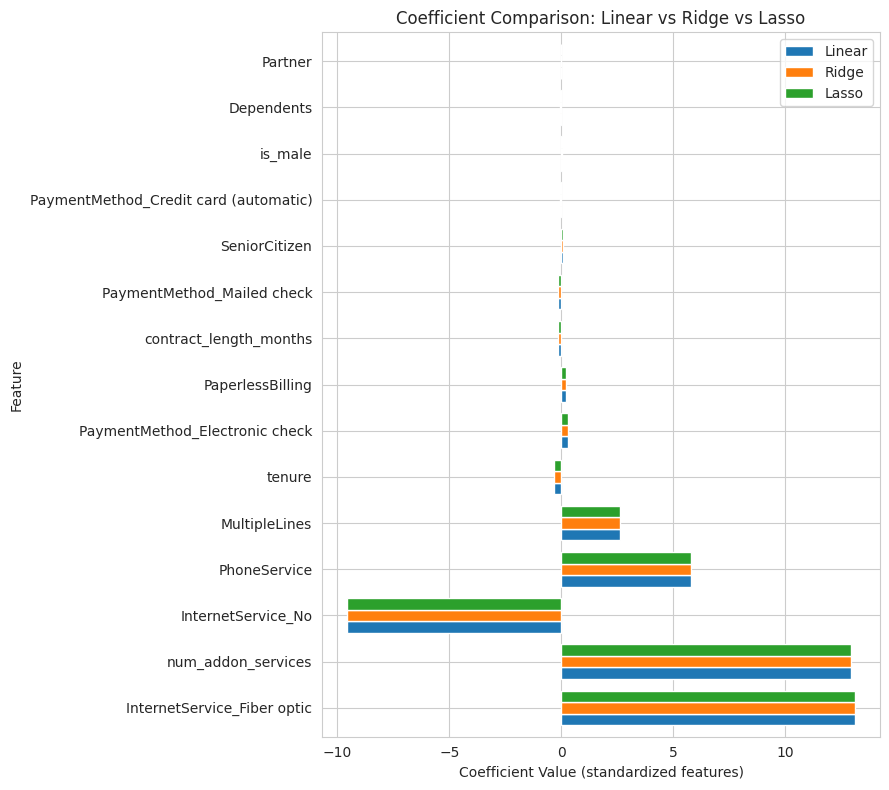

In [13]:
coef_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Linear": multiple_model.coef_,
    "Ridge": ridge_cv.coef_,
    "Lasso": lasso_cv.coef_,
}).set_index("Feature")

coef_df.sort_values("Linear", key=abs, ascending=False).plot(
    kind="barh", figsize=(9, 8), width=0.75
)
plt.title("Coefficient Comparison: Linear vs Ridge vs Lasso")
plt.xlabel("Coefficient Value (standardized features)")
plt.tight_layout()
plt.show()


**How alpha affects the models:** `RidgeCV` and `LassoCV` search a wide range of alpha
values (0.001 to 1000) and pick the one that minimizes cross-validated error. Ridge shrinks
all coefficients toward zero without eliminating any of them, which keeps every engineered
feature in play but reduces the influence of the more collinear ones. Lasso can shrink
coefficients all the way to exactly zero, which effectively performs feature selection —
useful for identifying which engineered features carry the least independent signal once
the others are accounted for.

## 8. Cross-Validation — Assessing Generalization

A single train/test split can be sensitive to which rows happen to land in the test set.
5-fold cross-validation is used across all four models on the full dataset to get a more
robust estimate of how well each model generalizes to unseen data.

In [14]:
X_full_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Baseline Linear": (LinearRegression(), X_full_scaled[baseline_features]),
    "Multiple Regression": (LinearRegression(), X_full_scaled),
    f"Ridge (alpha={ridge_cv.alpha_:.3f})": (Ridge(alpha=ridge_cv.alpha_), X_full_scaled),
    f"Lasso (alpha={lasso_cv.alpha_:.3f})": (Lasso(alpha=lasso_cv.alpha_, max_iter=10000), X_full_scaled),
}

cv_summary = []
cv_r2_raw = {}

for name, (model, features) in cv_models.items():
    r2_scores = cross_val_score(model, features, y, cv=kf, scoring="r2")
    neg_mse_scores = cross_val_score(model, features, y, cv=kf, scoring="neg_mean_squared_error")
    rmse_scores = np.sqrt(-neg_mse_scores)

    cv_r2_raw[name] = r2_scores
    cv_summary.append({
        "Model": name,
        "Mean CV R2": r2_scores.mean(),
        "Std CV R2": r2_scores.std(),
        "Mean CV RMSE": rmse_scores.mean(),
        "Std CV RMSE": rmse_scores.std(),
    })

cv_summary_df = pd.DataFrame(cv_summary).set_index("Model").round(3)
cv_summary_df


,Mean CV R2,Std CV R2,Mean CV RMSE,Std CV RMSE
Model,,,,
Baseline Linear,0.179,0.016,27.233,0.398
Multiple Regression,0.992,0.001,2.602,0.063
Ridge (alpha=0.869),0.992,0.001,2.602,0.063
Lasso (alpha=0.003),0.992,0.001,2.602,0.063


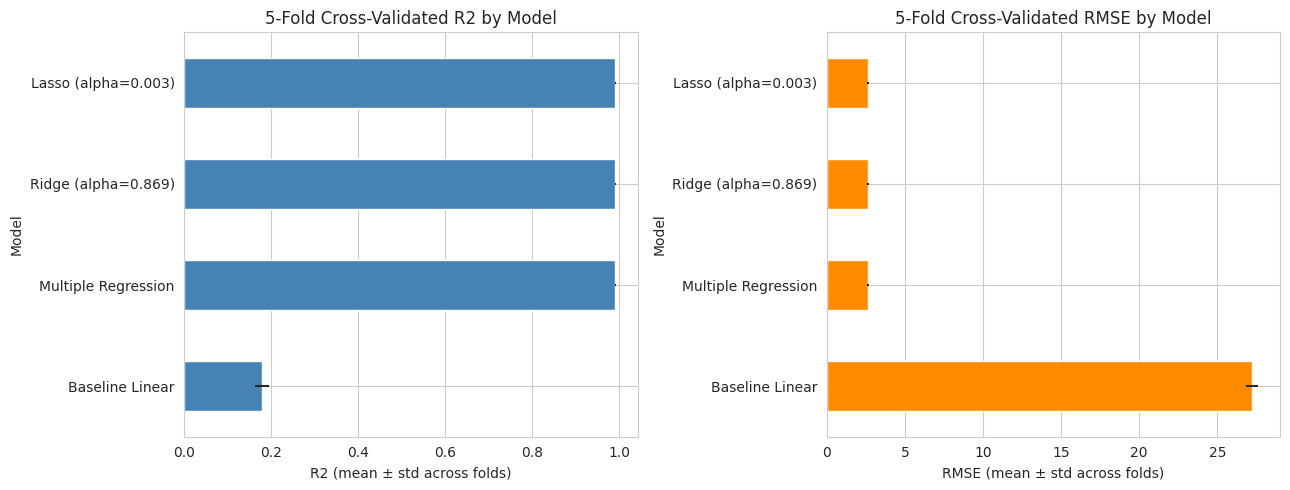

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cv_summary_df["Mean CV R2"].plot(kind="barh", ax=axes[0], color="steelblue", xerr=cv_summary_df["Std CV R2"])
axes[0].set_title("5-Fold Cross-Validated R2 by Model")
axes[0].set_xlabel("R2 (mean ± std across folds)")

cv_summary_df["Mean CV RMSE"].plot(kind="barh", ax=axes[1], color="darkorange", xerr=cv_summary_df["Std CV RMSE"])
axes[1].set_title("5-Fold Cross-Validated RMSE by Model")
axes[1].set_xlabel("RMSE (mean ± std across folds)")

plt.tight_layout()
plt.show()


/tmp/ipykernel_540/1945609611.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_r2_raw.values(), labels=cv_r2_raw.keys(), vert=False)


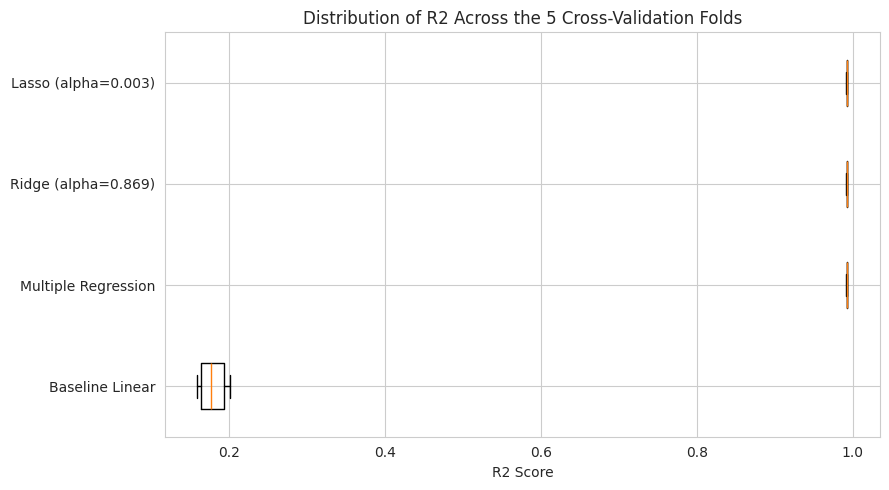

In [16]:
plt.figure(figsize=(9, 5))
plt.boxplot(cv_r2_raw.values(), labels=cv_r2_raw.keys(), vert=False)
plt.xlabel("R2 Score")
plt.title("Distribution of R2 Across the 5 Cross-Validation Folds")
plt.tight_layout()
plt.show()


## 9. Final Model Comparison

In [17]:
results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df


,MAE,MSE,RMSE,R2
Model,,,,
Baseline Linear Regression (raw features only),22.630,760.650,27.580,0.160
Multiple Regression (engineered features),1.973,7.102,2.665,0.992
Ridge Regression (alpha=0.8685),1.973,7.102,2.665,0.992
Lasso Regression (alpha=0.0031),1.972,7.101,2.665,0.992


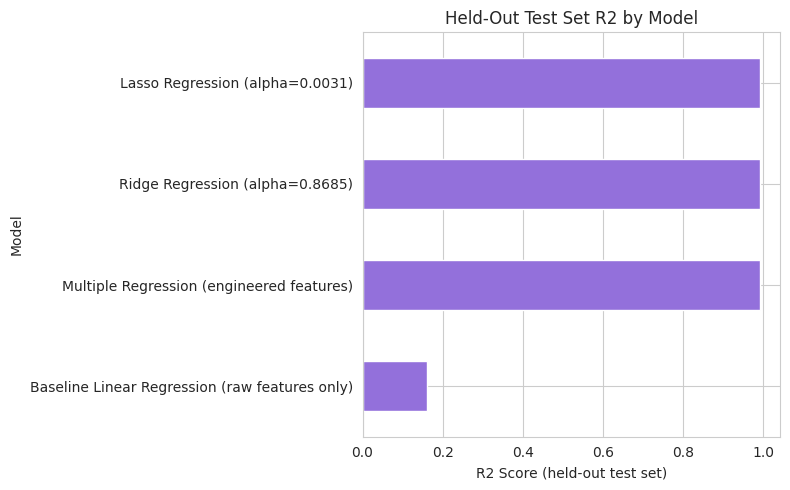

In [18]:
results_df["R2"].plot(kind="barh", figsize=(8, 5), color="mediumpurple")
plt.xlabel("R2 Score (held-out test set)")
plt.title("Held-Out Test Set R2 by Model")
plt.tight_layout()
plt.show()


## 10. Summary and Insights

**Which model performed best:** Multiple Regression, Ridge, and Lasso — all fit on the
engineered feature set — performed essentially identically (test R² ≈ 0.992, RMSE ≈ 2.67),
and all three dramatically outperformed the baseline (R² ≈ 0.16). Cross-validation confirmed
this: all three engineered models averaged R² = 0.992 with the same low fold-to-fold
variance (std ≈ 0.001). Lasso reached the same accuracy while zeroing out one of the
15 engineered features, making it the slightly more interpretable choice among an
otherwise tied field.

**Feature engineering impact:** moving from the 5 raw baseline features to the full
engineered feature set produced the single largest jump in R² and drop in RMSE of any step
in this notebook — larger than the improvement from regularization itself. This confirms
that `num_addon_services`, `contract_length_months`, and the one-hot encoded
`InternetService`/`PaymentMethod` columns carry most of the predictive signal for a
customer's monthly bill, consistent with the correlation analysis in Section 3.

**Value of regularization:** Ridge and Lasso matched, but did not exceed, the
unregularized Multiple Regression model's accuracy on this dataset, which suggests the
engineered feature set doesn't suffer from severe multicollinearity or overfitting on
~5,600 training rows with 15 features. Their practical benefit here was mainly Lasso's
automatic feature selection (zeroing out the weakest coefficient) rather than any gain in
raw accuracy — a useful property to have even when performance itself doesn't improve.

**Value of cross-validation:** the 5-fold cross-validation results closely tracked the
single train/test split results for every model, which is a good sign that the split used
throughout this notebook wasn't an unusually easy or hard one, and that the reported
metrics are a trustworthy estimate of real-world generalization.

**Dataset insight:** the strongest predictors of `MonthlyCharges` — fiber internet and the
number of add-on services — are also, per Deliverable 1's EDA, associated with *higher*
churn. That connection (premium, higher-billing customers churning at elevated rates) is
worth carrying forward into the classification deliverable.